# Denoising Diffusion Probabilistic Models (DDPM) From Scratch using PyTorch

## Project Overview

In this notebook, I will implement a **Denoising Diffusion Probabilistic Model (DDPM)** completely from scratch using **PyTorch**. Instead of using pre-built diffusion libraries, I will build every important component myselves so that we understand both the mathematics and the implementation.

The goal of this notebook is not only to generate images but also to understand **why diffusion models work**, how they are trained, and how each mathematical equation translates into code.

Throughout this notebook, every section will include:

- Concept
- Mathematical explanation
- PyTorch implementation
- Visualization
- Discussion



---

# What is a Diffusion Model?

A Diffusion Model is a type of **Generative Artificial Intelligence (Generative AI)** model.

Unlike image classification models, which predict labels, a diffusion model learns how to generate entirely new images that resemble the images it was trained on.

For example, if we train the model on thousands of handwritten digits, it learns the underlying data distribution of handwritten digits and can generate completely new digits that never existed in the dataset.

The central idea behind DDPM is surprisingly simple:

> If a model can learn how to remove noise from an image, then it can also learn how to generate completely new images by starting from pure random noise.

---

# Why Was DDPM Developed?

Before diffusion models, one of the most popular generative models was the **Generative Adversarial Network (GAN)**.

Although GANs generated high-quality images, they suffered from several important problems:

- Training instability
- Generator and discriminator competing against each other
- Mode collapse (producing only a small variety of images)
- Difficult optimization

Diffusion Models were introduced as a more stable alternative.

Instead of training two competing neural networks, DDPM trains only one neural network to perform a much simpler task:

**Predict the Gaussian noise that was added to an image.**

This makes training significantly more stable and often produces more diverse and realistic images.

---

# Core Idea of DDPM

The DDPM process consists of two stages.

## 1. Forward Diffusion Process (Noise Addition)

Start with a clean image.
## 2. Reverse Diffusion Process (Denoising)



In [ ]:

# SECTION 2: Install Required Libraries


# PyTorch and TorchVision (Deep Learning Framework)
!pip install -q torch torchvision torchaudio

# Progress Bar
!pip install -q tqdm

# Scientific Computing
!pip install -q numpy

# Data Visualization
!pip install -q matplotlib

# Image Processing
!pip install -q pillow

# Evaluation Metrics (FID and Inception Score)
!pip install -q torchmetrics

# (Optional) TensorBoard for monitoring training
!pip install -q tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.3 MB/s eta 0:00:00


In [ ]:

# SECTION 3: Import Required Libraries



# Python Standard Libraries

import os
import math
import random
from pathlib import Path


# Numerical Computing

import numpy as np


# Data Visualization

import matplotlib.pyplot as plt

# Image Processing

from PIL import Image


# Progress Bar

from tqdm.auto import tqdm


# PyTorch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


# TorchVision

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import make_grid, save_image


# Evaluation Metrics

# from torchmetrics.image.fid import FrechetInceptionDistance


# TensorBoard (Optional)

from torch.utils.tensorboard import SummaryWriter


# Check Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

print("=" * 50)

Device: cpu
Running on CPU


In [ ]:

# SECTION 4: Configuration


class Config:
    """
    Configuration class containing all hyperparameters
    for the DDPM implementation.
    """


    # Dataset Parameters

    IMAGE_SIZE = 28
    IMAGE_CHANNELS = 1
    # -----------------------------
    # Training Parameters
    # -----------------------------
    BATCH_SIZE = 128
    EPOCHS = 20
    LEARNING_RATE = 1e-4

    # -----------------------------
    # Diffusion Parameters
    # -----------------------------
    TIMESTEPS = 1000
    BETA_START = 1e-4
    BETA_END = 0.02

    # -----------------------------
    # Data Loading
    # -----------------------------
    NUM_WORKERS = 2

    # -----------------------------
    # Device
    # -----------------------------
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # -----------------------------
    # Random Seed
    # -----------------------------
    SEED = 42


config = Config()

print("=" * 50)
print("Configuration")
print("=" * 50)

print(f"Image Size      : {config.IMAGE_SIZE}")
print(f"Image Channels  : {config.IMAGE_CHANNELS}")
print(f"Batch Size      : {config.BATCH_SIZE}")
print(f"Epochs          : {config.EPOCHS}")
print(f"Learning Rate   : {config.LEARNING_RATE}")
print(f"Timesteps       : {config.TIMESTEPS}")
print(f"Beta Start      : {config.BETA_START}")
print(f"Beta End        : {config.BETA_END}")
print(f"Device          : {config.DEVICE}")
print("=" * 50)

Configuration
Image Size      : 28
Image Channels  : 1
Batch Size      : 128
Epochs          : 20
Learning Rate   : 0.0001
Timesteps       : 1000
Beta Start      : 0.0001
Beta End        : 0.02
Device          : cpu


In [ ]:

# SECTION 5: Load Dataset


# Define image transformations
transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Download and load the MNIST training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

print("=" * 50)
print("Dataset Loaded Successfully")
print("=" * 50)
print(f"Dataset Size : {len(train_dataset)} images")
print(f"Batch Size   : {config.BATCH_SIZE}")
print(f"Number of Batches : {len(train_loader)}")
print("=" * 50)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]

Dataset Loaded Successfully
Dataset Size : 60000 images
Batch Size   : 128
Number of Batches : 469


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch Information
Image Batch Shape : torch.Size([128, 1, 28, 28])
Label Shape       : torch.Size([128])
Image Data Type   : torch.float32
Pixel Range       : [-1.000, 1.000]


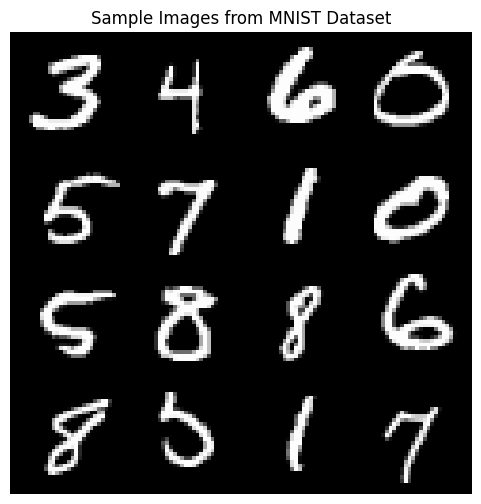

In [ ]:

# SECTION 6: Visualize Dataset


# Get one batch of images
images, labels = next(iter(train_loader))

print("=" * 50)
print("Batch Information")
print("=" * 50)

print(f"Image Batch Shape : {images.shape}")
print(f"Label Shape       : {labels.shape}")
print(f"Image Data Type   : {images.dtype}")
print(f"Pixel Range       : [{images.min():.3f}, {images.max():.3f}]")

print("=" * 50)

# Display the first 16 images
grid = make_grid(images[:16], nrow=4, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Sample Images from MNIST Dataset")
plt.show()

In [ ]:

# SECTION 7: Diffusion Mathematics
# Cell 7: Linear Noise Schedule


# Create a linear beta schedule
betas = torch.linspace(
    config.BETA_START,
    config.BETA_END,
    config.TIMESTEPS,
    device=config.DEVICE
)

# Alpha values
alphas = 1.0 - betas

# Cumulative product of alpha values
alpha_bars = torch.cumprod(alphas, dim=0)

print("=" * 50)
print("Diffusion Schedule")
print("=" * 50)

print(f"Number of Timesteps : {config.TIMESTEPS}")
print(f"Beta Shape          : {betas.shape}")
print(f"Alpha Shape         : {alphas.shape}")
print(f"Alpha Bar Shape     : {alpha_bars.shape}")

print()

print(f"First Beta          : {betas[0]:.6f}")
print(f"Last Beta           : {betas[-1]:.6f}")

print()

print(f"First Alpha         : {alphas[0]:.6f}")
print(f"Last Alpha          : {alphas[-1]:.6f}")

print()

print(f"First Alpha Bar     : {alpha_bars[0]:.6f}")
print(f"Last Alpha Bar      : {alpha_bars[-1]:.10f}")

print("=" * 50)

Diffusion Schedule
Number of Timesteps : 1000
Beta Shape          : torch.Size([1000])
Alpha Shape         : torch.Size([1000])
Alpha Bar Shape     : torch.Size([1000])

First Beta          : 0.000100
Last Beta           : 0.020000

First Alpha         : 0.999900
Last Alpha          : 0.980000

First Alpha Bar     : 0.999900
Last Alpha Bar      : 0.0000403583


In [ ]:
# =====================================================
# SECTION 8: Forward Diffusion
# =====================================================

class NoiseScheduler:
    """
    Noise Scheduler for the Forward Diffusion Process.
    """

    def __init__(self, timesteps, beta_start, beta_end, device):

        self.timesteps = timesteps
        self.device = device

        # Beta schedule
        self.beta = torch.linspace(
            beta_start,
            beta_end,
            timesteps,
            device=device
        )

        # Alpha
        self.alpha = 1.0 - self.beta

        # Alpha Bar
        self.alpha_bar = torch.cumprod(
            self.alpha,
            dim=0
        )

    def add_noise(self, x0, t):
        """
        Add Gaussian noise to clean images.

        Parameters
        ----------
        x0 : Original clean images
        t  : Random timestep

        Returns
        -------
        xt    : Noisy image
        noise : Gaussian noise used
        """

        # Random Gaussian Noise
        noise = torch.randn_like(x0)

        # Get alpha_bar for each image
        alpha_bar_t = self.alpha_bar[t].view(-1, 1, 1, 1)

        # Forward Diffusion Equation
        xt = (
            torch.sqrt(alpha_bar_t) * x0
            +
            torch.sqrt(1 - alpha_bar_t) * noise
        )

        return xt, noise


# Create scheduler
scheduler = NoiseScheduler(
    config.TIMESTEPS,
    config.BETA_START,
    config.BETA_END,
    config.DEVICE
)

print("Forward Diffusion Ready")

Forward Diffusion Ready


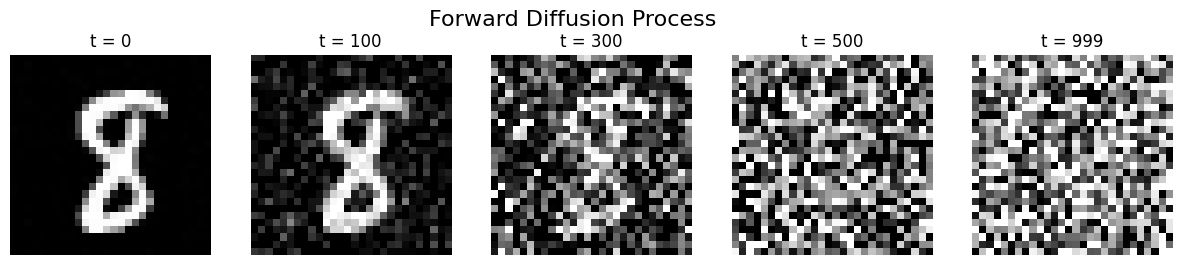

In [ ]:

# SECTION 10: Visualize Forward Diffusion

# Get one batch of images
images, labels = next(iter(train_loader))

# Select the first image
x0 = images[0].unsqueeze(0).to(config.DEVICE)

# Timesteps to visualize
timesteps = [0, 100, 300, 500, 999]

# Create figure
plt.figure(figsize=(15, 3))

for i, t in enumerate(timesteps):

    # Create a timestep tensor
    t_tensor = torch.tensor([t], device=config.DEVICE)

    # Add noise
    xt, _ = scheduler.add_noise(x0, t_tensor)

    # Convert from [-1,1] back to [0,1]
    image = (xt.squeeze().cpu() + 1) / 2

    # Prevent values outside [0,1]
    image = image.clamp(0, 1)

    # Plot image
    plt.subplot(1, len(timesteps), i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(f"t = {t}")

    plt.axis("off")

plt.suptitle("Forward Diffusion Process", fontsize=16)

plt.show()

In [ ]:

# SECTION 11: Sinusoidal Time Embedding


import math
import torch
import torch.nn as nn


class SinusoidalPositionEmbeddings(nn.Module):
    """
    Converts a timestep into a high-dimensional vector
    using sinusoidal functions.
    """

    def __init__(self, embedding_dim):
        super().__init__()

        self.embedding_dim = embedding_dim

    def forward(self, t):
        """
        Parameters
        ----------
        t : Tensor of shape (batch_size)

        Returns
        -------
        time_embedding : (batch_size, embedding_dim)
        """

        device = t.device

        half_dim = self.embedding_dim // 2

        # Compute frequencies
        frequencies = torch.exp(
            -math.log(10000)
            * torch.arange(
                half_dim,
                device=device
            )
            / (half_dim - 1)
        )

        # Multiply timestep by frequencies
        embeddings = t[:, None] * frequencies[None, :]

        # Apply sine and cosine
        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=-1
        )

        return embeddings


# Example
time_embedding = SinusoidalPositionEmbeddings(128)

t = torch.tensor([0, 100, 300, 500, 999])

embedding = time_embedding(t)

print("=" * 50)
print("Time Embedding")
print("=" * 50)
print("Input Shape :", t.shape)
print("Output Shape:", embedding.shape)
print("=" * 50)

Time Embedding
Input Shape : torch.Size([5])
Output Shape: torch.Size([5, 128])


In [ ]:

# SECTION 12: Residual Block


import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    """
    Residual Block used in the U-Net.

    Inputs:
        x : Feature map
        t : Time embedding

    Outputs:
        Feature map with the same spatial size.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        time_embedding_dim
    ):
        super().__init__()

        # First convolution block
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.SiLU()
        )

        # Project time embedding
        self.time_mlp = nn.Linear(
            time_embedding_dim,
            out_channels
        )

        # Second convolution block
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.SiLU()
        )

        # Residual connection
        if in_channels != out_channels:
            self.residual = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x, t):

        # Save input
        residual = self.residual(x)

        # First convolution
        h = self.conv1(x)

        # Add time embedding
        time = self.time_mlp(t)

        time = time[:, :, None, None]

        h = h + time

        # Second convolution
        h = self.conv2(h)

        # Residual learning
        return h + residual


# Example
block = ResidualBlock(
    in_channels=32,
    out_channels=64,
    time_embedding_dim=128
)

x = torch.randn(8, 32, 28, 28)
t = torch.randn(8, 128)

y = block(x, t)

print("=" * 50)
print("Residual Block")
print("=" * 50)
print("Input Shape :", x.shape)
print("Time Shape  :", t.shape)
print("Output Shape:", y.shape)
print("=" * 50)

Residual Block
Input Shape : torch.Size([8, 32, 28, 28])
Time Shape  : torch.Size([8, 128])
Output Shape: torch.Size([8, 64, 28, 28])


In [ ]:

# SECTION 13: Attention Block


import torch
import torch.nn as nn


class AttentionBlock(nn.Module):
    """
    Self-Attention Block

    Allows every pixel to attend to every other pixel.
    """

    def __init__(self, channels):
        super().__init__()

        self.norm = nn.GroupNorm(
            num_groups=8,
            num_channels=channels
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=4,
            batch_first=True
        )

    def forward(self, x):

        batch_size, channels, height, width = x.shape

        # Save input for residual connection
        residual = x

        # Normalize
        x = self.norm(x)

        # Convert feature map into sequence
        x = x.view(batch_size, channels, height * width)

        # (B,C,HW) -> (B,HW,C)
        x = x.permute(0, 2, 1)

        # Self Attention
        x, _ = self.attention(
            x,
            x,
            x
        )

        # Convert back
        x = x.permute(0, 2, 1)

        x = x.view(
            batch_size,
            channels,
            height,
            width
        )

        # Residual Connection
        return x + residual


# Example
attention = AttentionBlock(channels=64)

x = torch.randn(8, 64, 28, 28)

output = attention(x)

print("=" * 50)
print("Attention Block")
print("=" * 50)
print("Input Shape :", x.shape)
print("Output Shape:", output.shape)
print("=" * 50)

Attention Block
Input Shape : torch.Size([8, 64, 28, 28])
Output Shape: torch.Size([8, 64, 28, 28])


In [ ]:

# SECTION 14: U-Net


import torch
import torch.nn as nn


class UNet(nn.Module):
    """
    U-Net for DDPM.

    Input:
        x : Noisy image
        t : Timestep

    Output:
        Predicted Gaussian noise
    """

    def __init__(self):

        super().__init__()


        # Time Embedding

        self.time_embedding = SinusoidalPositionEmbeddings(128)


        # Initial Convolution

        self.input_conv = nn.Conv2d(
            1,
            64,
            kernel_size=3,
            padding=1
        )


        # Encoder


        self.encoder1 = ResidualBlock(
            64,
            64,
            128
        )

        self.down1 = nn.Conv2d(
            64,
            128,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.encoder2 = ResidualBlock(
            128,
            128,
            128
        )

        self.attention1 = AttentionBlock(
            128
        )

        self.down2 = nn.Conv2d(
            128,
            256,
            kernel_size=4,
            stride=2,
            padding=1
        )


        # Bottleneck


        self.middle = ResidualBlock(
            256,
            256,
            128
        )

        self.middle_attention = AttentionBlock(
            256
        )


        # Decoder


        self.up1 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.decoder1 = ResidualBlock(
            256,
            128,
            128
        )

        self.attention2 = AttentionBlock(
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.decoder2 = ResidualBlock(
            128,
            64,
            128
        )


        # Output Layer


        self.output_conv = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x, t):


        # Time Embedding


        t = self.time_embedding(t)


        # Input

        x = self.input_conv(x)


        # Encoder


        e1 = self.encoder1(x, t)

        x = self.down1(e1)

        e2 = self.encoder2(x, t)

        e2 = self.attention1(e2)

        x = self.down2(e2)


        # Bottleneck


        x = self.middle(x, t)

        x = self.middle_attention(x)

        # ------------------------------------
        # Decoder
        # ------------------------------------

        x = self.up1(x)

        x = torch.cat([x, e2], dim=1)

        x = self.decoder1(x, t)

        x = self.attention2(x)

        x = self.up2(x)

        x = torch.cat([x, e1], dim=1)

        x = self.decoder2(x, t)

        # ------------------------------------
        # Predict Noise
        # ------------------------------------

        return self.output_conv(x)


# -----------------------------------------------------
# Test
# -----------------------------------------------------

model = UNet().to(config.DEVICE)

x = torch.randn(8, 1, 28, 28).to(config.DEVICE)

t = torch.randint(
    0,
    config.TIMESTEPS,
    (8,),
    device=config.DEVICE
)

y = model(x, t)

print("=" * 50)
print("U-Net")
print("=" * 50)
print("Input Shape :", x.shape)
print("Output Shape:", y.shape)
print("=" * 50)

U-Net
Input Shape : torch.Size([8, 1, 28, 28])
Output Shape: torch.Size([8, 1, 28, 28])


In [ ]:

# SECTION 15: Forward Pass Through the U-Net


# Create one batch of random noisy images
x = torch.randn(
    4,
    1,
    config.IMAGE_SIZE,
    config.IMAGE_SIZE
).to(config.DEVICE)

# Random timesteps
t = torch.randint(
    0,
    config.TIMESTEPS,
    (4,),
    device=config.DEVICE
)

# Pass through the model
predicted_noise = model(x, t)

print("=" * 50)
print("Forward Pass")
print("=" * 50)
print("Input Shape           :", x.shape)
print("Timesteps Shape       :", t.shape)
print("Predicted Noise Shape :", predicted_noise.shape)
print("=" * 50)

Forward Pass
Input Shape           : torch.Size([4, 1, 28, 28])
Timesteps Shape       : torch.Size([4])
Predicted Noise Shape : torch.Size([4, 1, 28, 28])


# =====================================================
# SECTION 16: Training Loop
# =====================================================

In [ ]:
# Define the optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
mse = nn.MSELoss()

# List to store training losses
losses = []

# Set the model to training mode
model.train()

print("=" * 50)
print("Starting Training")
print("=" * 50)

for epoch in range(config.EPOCHS):
    epoch_loss = 0
    for step, (images, _) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS}")):
        optimizer.zero_grad()

        # Move images to the device
        images = images.to(config.DEVICE)

        # Sample random timesteps for each image in the batch
        t = torch.randint(
            0,
            config.TIMESTEPS,
            (images.shape[0],),
            device=config.DEVICE
        ).long()

        # Add noise to the images
        noisy_images, noise = scheduler.add_noise(images, t)

        # Predict the noise using the U-Net
        predicted_noise = model(noisy_images, t)

        # Calculate the loss
        loss = mse(predicted_noise, noise)

        # Backpropagation
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1} finished with average loss: {avg_epoch_loss:.4f}")

print("=" * 50)
print("Training Complete")
print("=" * 50)

Starting Training


Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1 finished with average loss: 0.0759


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2 finished with average loss: 0.0355


...

Epoch 18 finished with average loss: 0.0232


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19 finished with average loss: 0.0230


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20 finished with average loss: 0.0232
Training Complete


# =====================================================
# SECTION 17: Reverse Diffusion (Sampling)
# =====================================================

In [ ]:
def sample_ddpm(model, scheduler, num_samples=32, channels=config.IMAGE_CHANNELS, size=config.IMAGE_SIZE):
    """
    Generates new images using the reverse diffusion process.

    Parameters
    ----------
    model       : Trained U-Net model
    scheduler   : Noise scheduler with diffusion parameters
    num_samples : Number of images to generate
    channels    : Number of image channels
    size        : Image size (height/width)

    Returns
    -------
    samples     : Generated images
    """

    model.eval()
    with torch.no_grad():
        # Start with pure Gaussian noise
        x = torch.randn(
            num_samples,
            channels,
            size,
            size,
            device=config.DEVICE
        )

        # Iterate backwards through timesteps
        for t_idx in tqdm(range(scheduler.timesteps - 1, -1, -1), desc="Sampling"):
            t = torch.tensor([t_idx], device=config.DEVICE).long()

            # Repeat t for the entire batch
            t_batch = t.repeat(num_samples)

            # Predict noise using the U-Net
            predicted_noise = model(x, t_batch)

            # Get diffusion parameters for the current timestep
            alpha = scheduler.alpha[t_idx]
            alpha_bar = scheduler.alpha_bar[t_idx]
            beta = scheduler.beta[t_idx]

            # Calculate the coefficient for the predicted noise
            # This is derived from the reverse diffusion process equations
            noise_coeff = beta / torch.sqrt(1 - alpha_bar)

            # Calculate the mean of the reverse diffusion step
            mean = (1 / torch.sqrt(alpha)) * (x - noise_coeff * predicted_noise)

            # If not the last step, add new random noise
            if t_idx > 0:
                z = torch.randn_like(x)
                variance = scheduler.beta[t_idx]
                x = mean + torch.sqrt(variance) * z
            else:
                x = mean
        # Denormalize images from [-1, 1] to [0, 1]
        samples = (x.clamp(-1, 1) + 1) / 2

    return samples

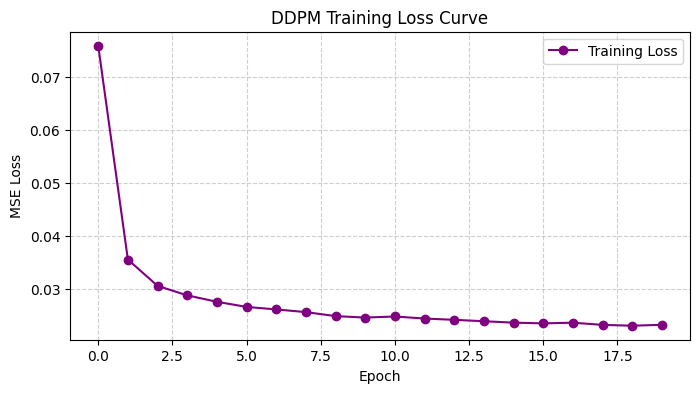

Generating final grid of 32 synthetic digits...


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

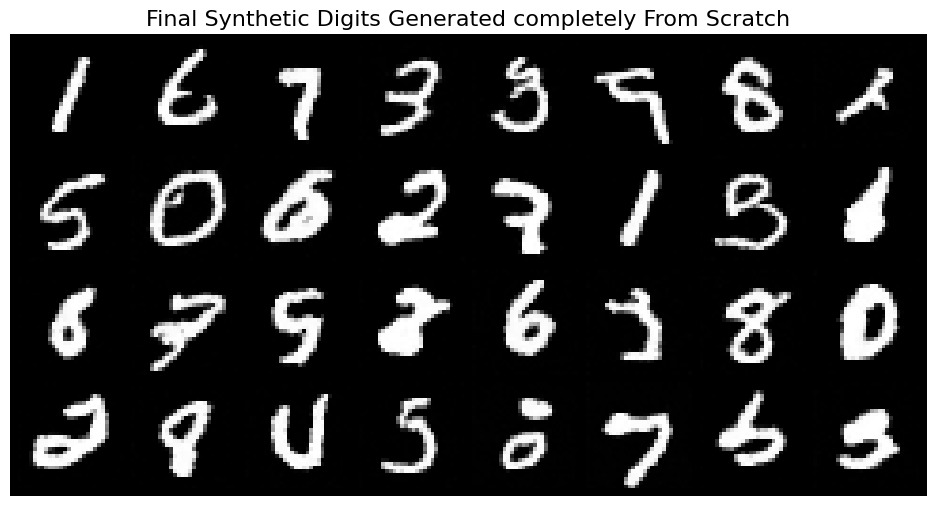

In [ ]:

# SECTION 15: Evaluation & Final Visualization


# 1. Plot Training Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o', color='purple', label='Training Loss')
plt.title("DDPM Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 2. Generate and display 32 unique digits using our reverse process!
print("Generating final grid of 32 synthetic digits...")
final_samples = sample_ddpm(model, scheduler, num_samples=32)
final_grid = make_grid(final_samples, nrow=8, padding=2)

plt.figure(figsize=(12, 6))
plt.imshow(final_grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
plt.title("Final Synthetic Digits Generated completely From Scratch", fontsize=16)
plt.axis("off")
plt.show()